In [1]:
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
%cd ../scripts/
import sys
import os
sys.path.append("../")
sys.path.append("../Modules")
import analysis

/home/drfrbc/Neural-Modeling/scripts


In [3]:
# # provide a simulations folder (choose among the set)
# simulations_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-01-14-14-Running_5sec_STA_noRhyth"
# sim_index = input(f"Specify the simulation index (0-{len(os.listdir(simulations_dir))-1}): from among simulations {os.listdir(simulations_dir)}")
# sim_directory = os.path.join(simulations_dir, os.listdir(simulations_dir)[int(sim_index)])


# OR provide a simulation folder
sim_directory = "/home/drfrbc/Neural-Modeling/simulations/2025-06-09-13-55-no_clustering_30sec_sta/complex"
# sim_directory  = "/home/drfrbc/Neural-Modeling/simulations/2025-06-09-12-20-tuft_exc_clusters_30sec_sta/complex"
# sim_directory = "/home/drfrbc/Neural-Modeling/simulations/2025-06-10-12-28-tuft_clustering_30sec_sta_lower_oblique_exc_dens/complex"

sim_directory = "/home/drfrbc/Neural-Modeling/simulations/2025-10-16-08-28-IncreaseNexusMaxYTo950/allinh_rhythmic_depth_0.00_Np5000"

sim_directory = "/home/drfrbc/Neural-Modeling/simulations/2025-10-22-14-15-Testing_IncreaseTuftInh/allinh_delay_shift_4ms_Np5000"


In [4]:
# Generate .csv's for dendritic events
!python find_events_ben.py -d {sim_directory}

DataFrames already exist in /home/drfrbc/Neural-Modeling/simulations/2025-10-22-14-15-Testing_IncreaseTuftInh/allinh_delay_shift_4ms_Np5000. Skipping computation.


In [5]:

from Modules.analysis import load_sim
parameters, sim_data, seg_data, elec_dist = load_sim(sim_directory)

Loading data from /home/drfrbc/Neural-Modeling/simulations/2025-10-22-14-15-Testing_IncreaseTuftInh/allinh_delay_shift_4ms_Np5000


--No graphics will be displayed.


In [6]:
sim_data['spktimes']

array([5.20000e+00, 3.42000e+01, 3.94000e+01, 4.92000e+01, 9.20000e+01,
       9.57000e+01, 1.88000e+02, 1.94800e+02, 2.56400e+02, 2.74300e+02,
       3.89100e+02, 4.76500e+02, 5.04900e+02, 5.18000e+02, 5.85000e+02,
       5.91600e+02, 5.99000e+02, 7.31200e+02, 7.80100e+02, 7.87600e+02,
       7.98700e+02, 8.40500e+02, 1.01310e+03, 1.16010e+03, 1.27710e+03,
       1.28230e+03, 1.28930e+03, 1.37870e+03, 1.45270e+03, 1.46100e+03,
       1.46760e+03, 1.48360e+03, 1.64130e+03, 1.72940e+03, 1.75890e+03,
       1.76720e+03, 1.77610e+03, 1.92060e+03, 1.92840e+03, 2.00190e+03,
       2.00840e+03, 2.10480e+03, 2.13630e+03, 2.21750e+03, 2.22550e+03,
       2.23680e+03, 2.33050e+03, 2.37660e+03, 2.42840e+03, 2.45600e+03,
       2.52310e+03, 2.54420e+03, 2.56860e+03, 2.57530e+03, 2.64690e+03,
       2.70350e+03, 2.75890e+03, 2.83040e+03, 2.83880e+03, 2.87740e+03,
       2.94520e+03, 2.95360e+03, 3.00290e+03, 3.01150e+03, 3.02540e+03,
       3.15270e+03, 3.32010e+03, 3.43410e+03, 3.46010e+03, 3.468

In [7]:
dendritic_dfs = {
    "ca": pd.read_csv(os.path.join(sim_directory, "ca.csv")),
    "nmda": pd.read_csv(os.path.join(sim_directory, "nmda.csv")),
    "na": pd.read_csv(os.path.join(sim_directory, "na.csv")),
}

In [8]:
if not os.path.exists(os.path.join(sim_directory, "voltages")):
    os.makedirs(os.path.join(sim_directory, "voltages"))

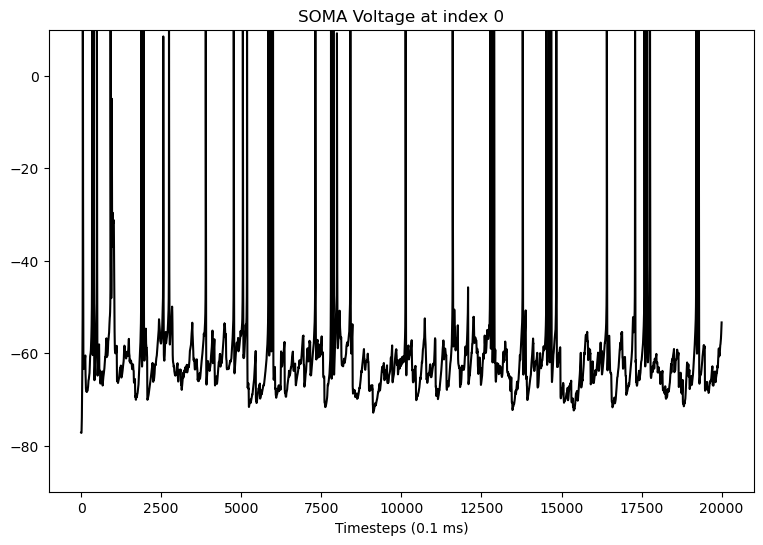

In [9]:
# plot soma voltage
time_points=np.arange(0,int(parameters.h_tstop/parameters.h_dt))
time_points = time_points[0:19999] # select time_points
# time_points = time_points[100000:149999]
# time_points = time_points[450000:499999]
colors = ['r*', 'g*', 'b*', 'm*', 'y*', 'k*']
plt.figure(figsize=(20, 6))

plt.subplot(1, 2, 2)
plt.plot(sim_data['v'][time_points, 0], colors[-1].split('*')[0])
plt.ylim([-90, 10])
plt.title(f'SOMA Voltage at index {0}')
plt.xlabel(f'Timesteps ({parameters.h_dt} ms)')
# plt.xlim(40000,50000)
plt.savefig(os.path.join(sim_directory, 'voltages', 'soma_voltage_init.png'), format='png', bbox_inches="tight", dpi=300)
# plt.show()

In [10]:
# spike rate

# Function to count the first occurrence of True in consecutive trues
def count_first_true(arr):
    return np.sum((arr > -10) & np.concatenate(([True], arr[:-1] <= -10)))

# Count the number of spikes in the soma
soma_spike_count = count_first_true(sim_data['v'][:, 0])
print(f"Soma spike count {soma_spike_count}")
sim_duration = len(sim_data['v'][:, 0])
print(f"Simulation duration in timesteps: {sim_duration}")
sim_duration_in_sec = sim_duration / ((1/parameters.h_dt) * 1000)
print(f"Simulation duration in seconds: {sim_duration_in_sec}")
soma_spike_rate = soma_spike_count / (len(sim_data['v'][:, 0]) / 10000)
print(f"Soma firing rate {round(soma_spike_rate, 3)}")

Soma spike count 982
Simulation duration in timesteps: 500001
Simulation duration in seconds: 50.0001
Soma firing rate 19.64


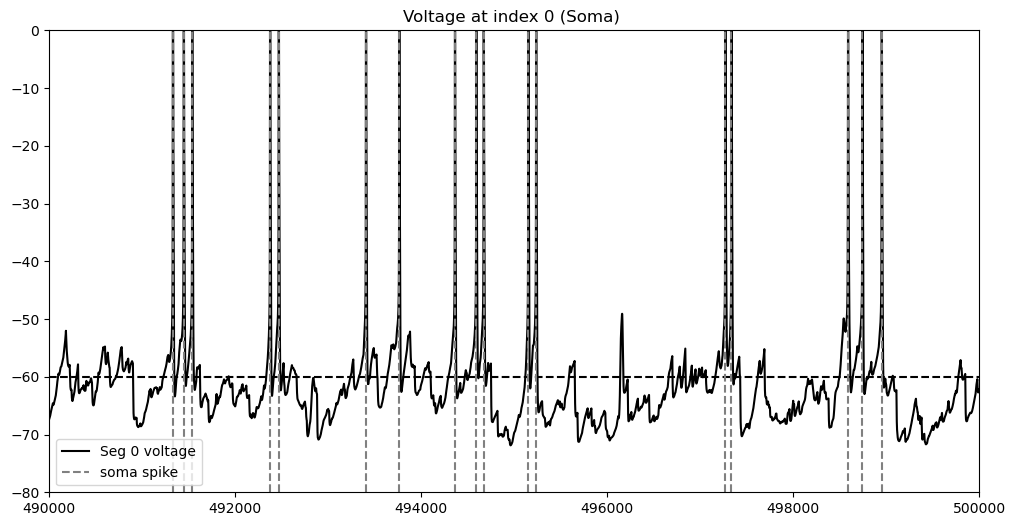

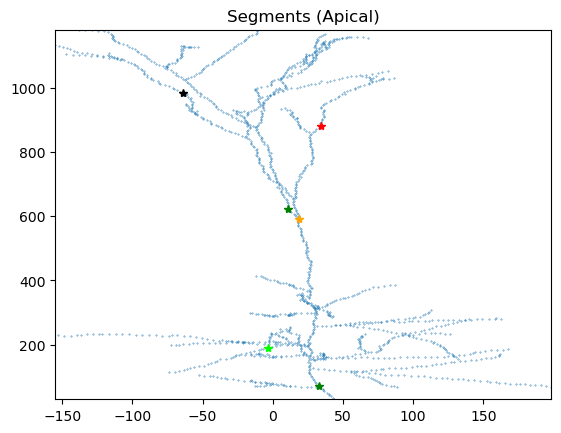

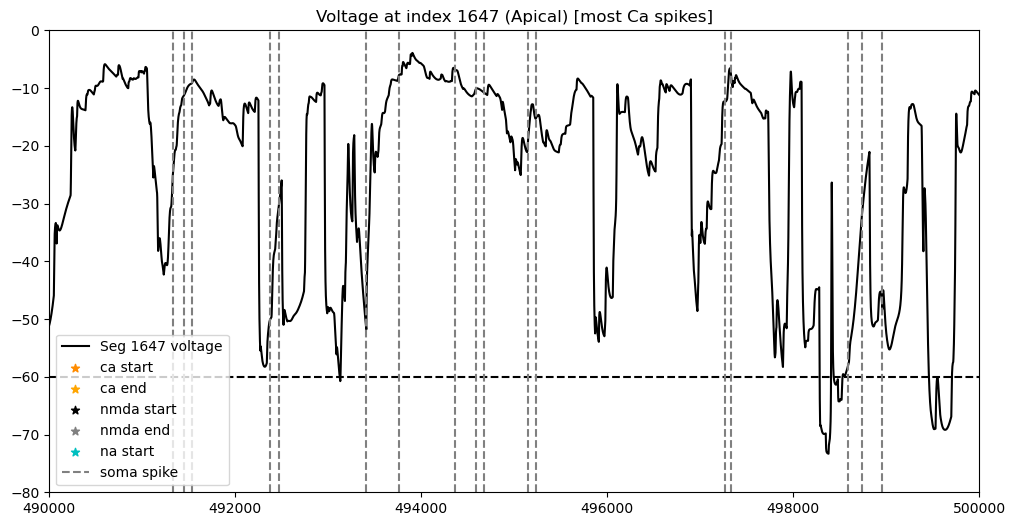

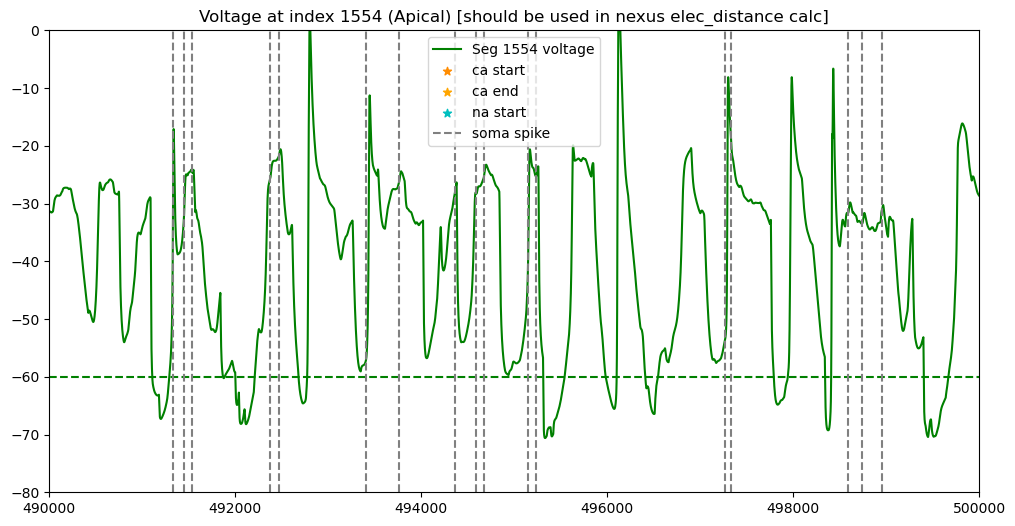

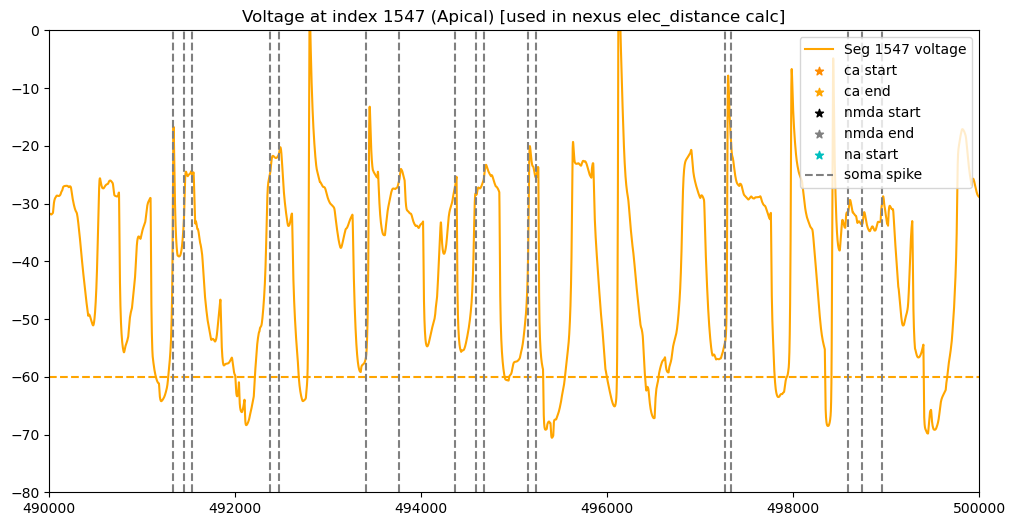

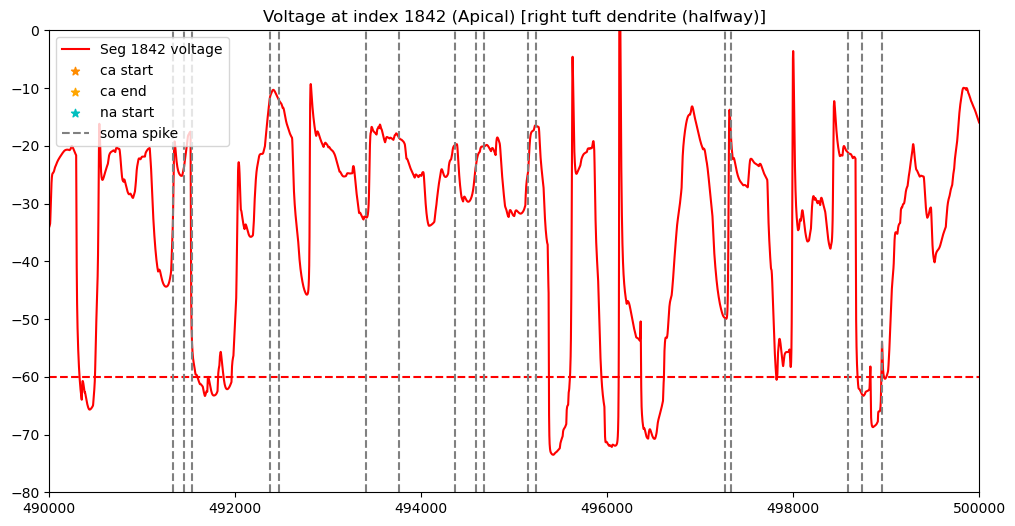

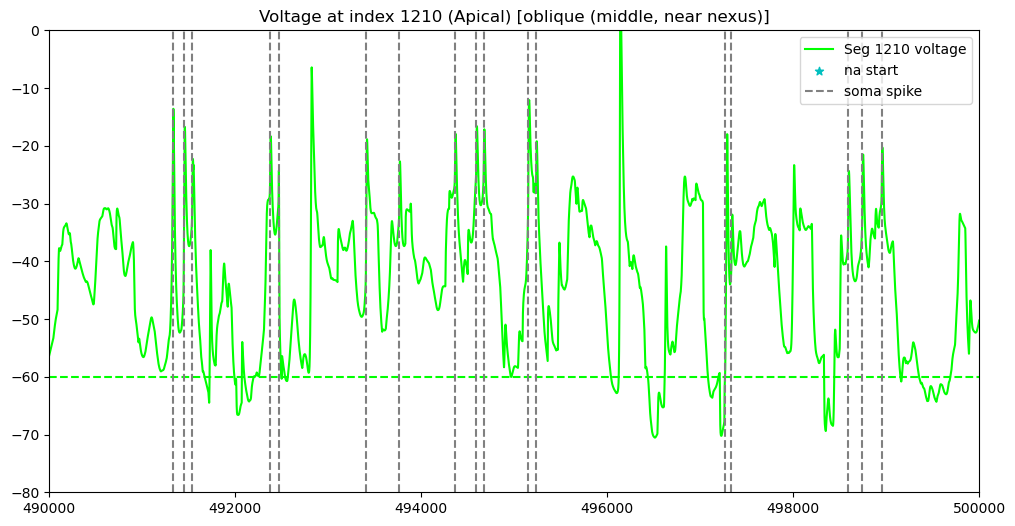

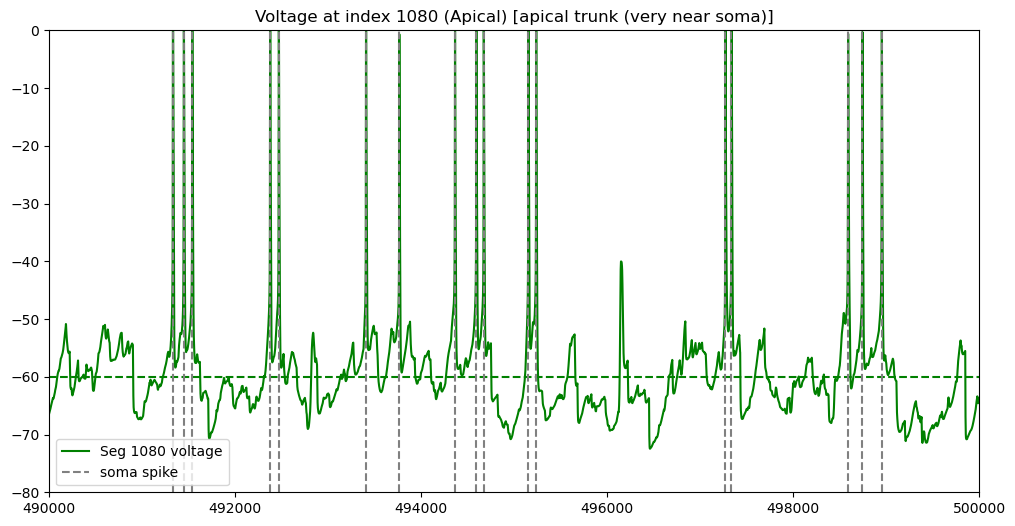

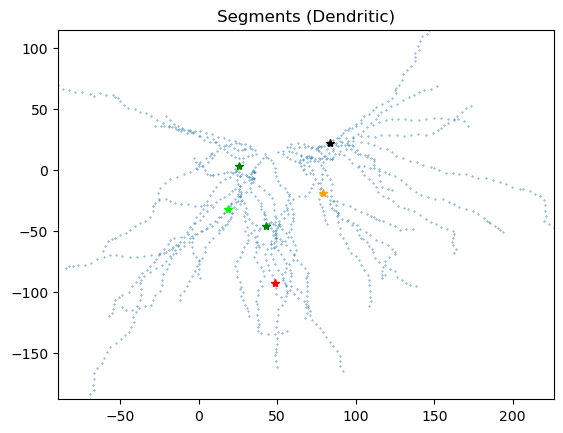

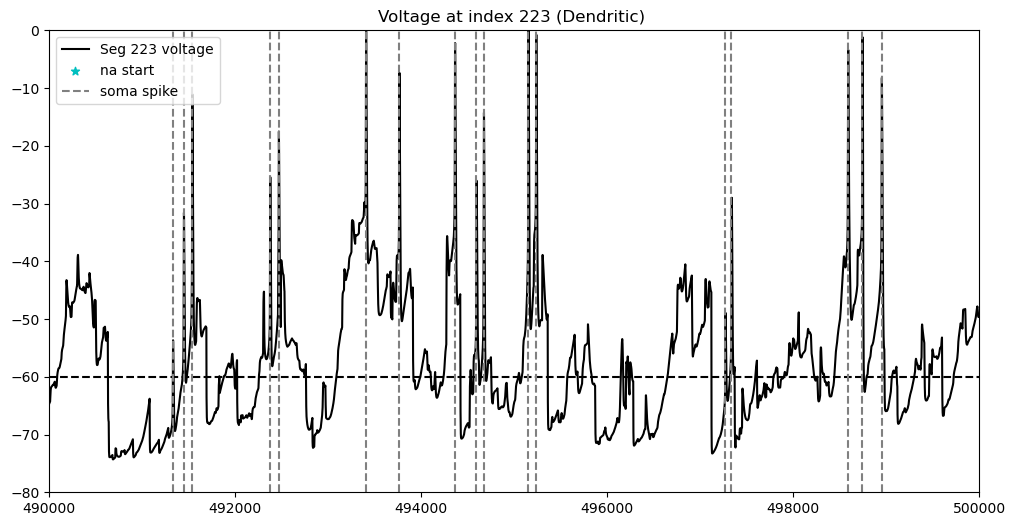

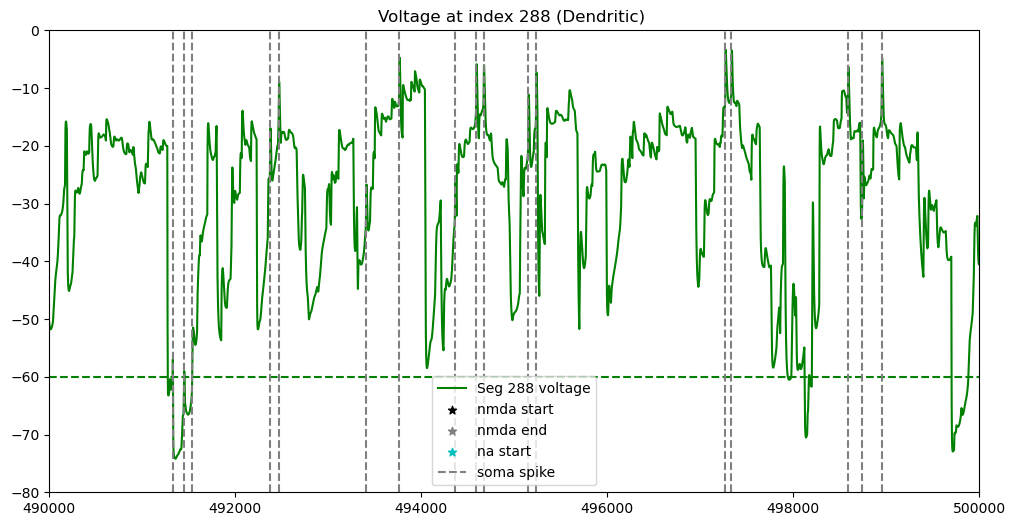

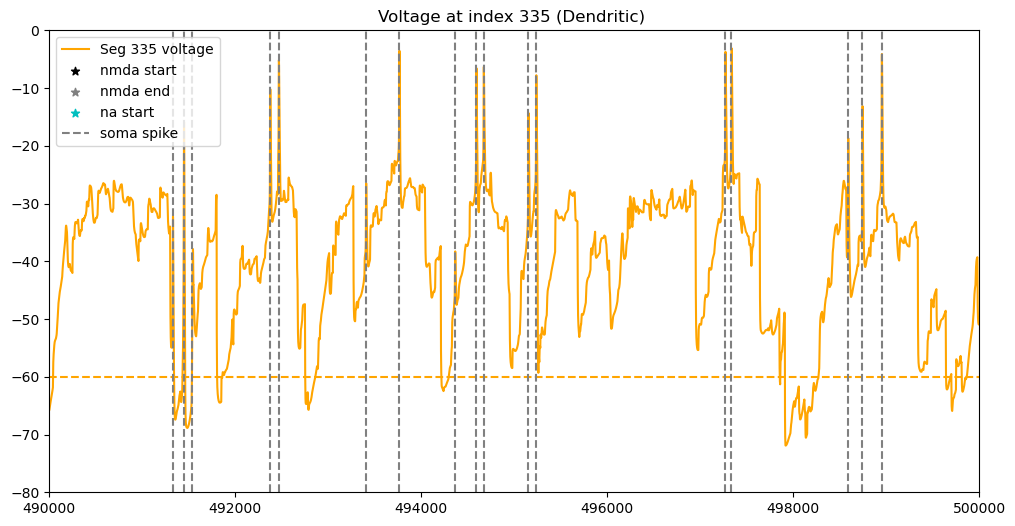

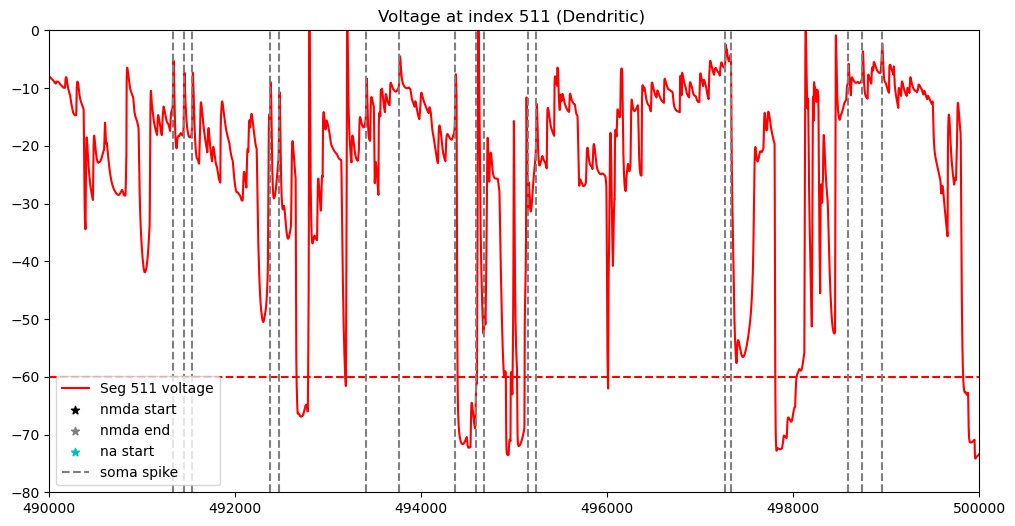

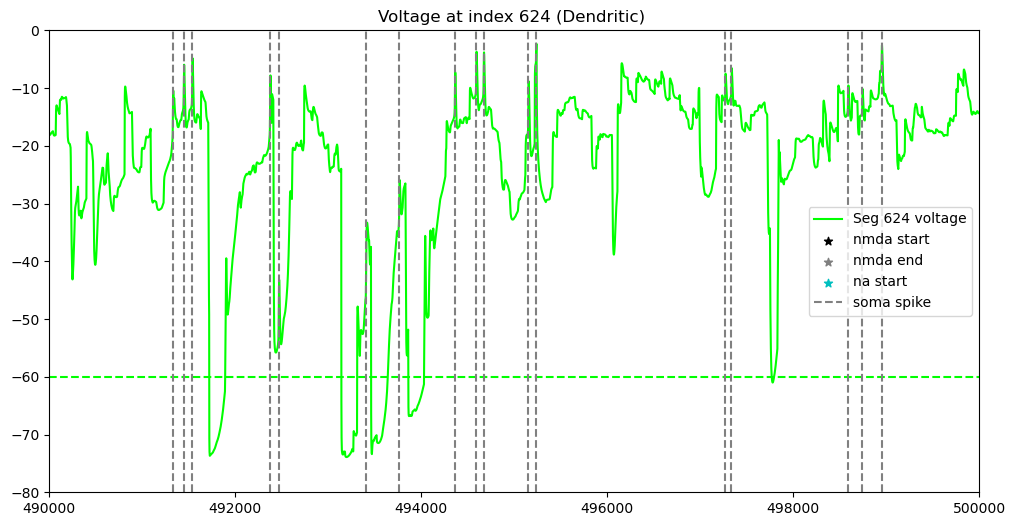

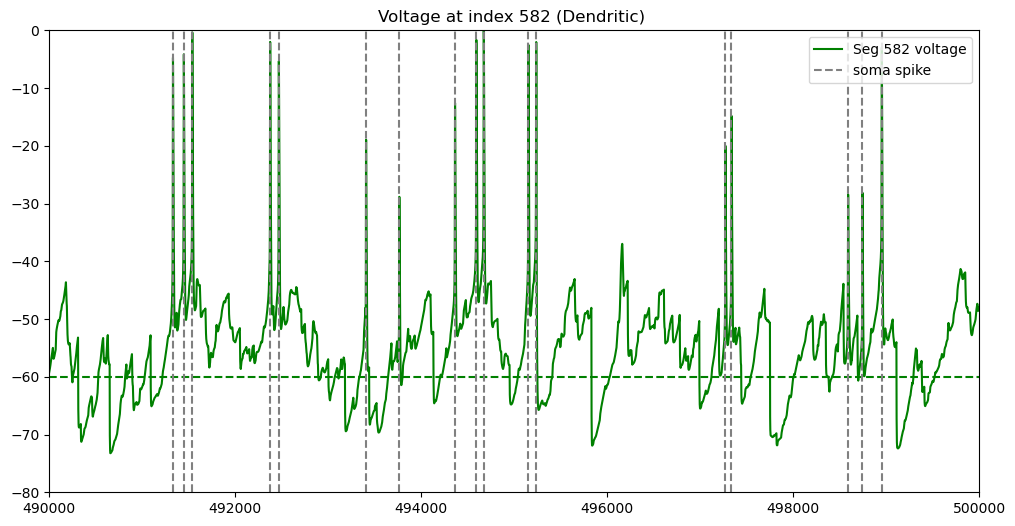

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Modules.plot_morphology import plot_segments
from Modules.plot_voltage import plot_voltage

xlimits = [(parameters.h_tstop/parameters.h_dt)-(1000/parameters.h_dt), parameters.h_tstop/parameters.h_dt]  # last 1000 ms

# Filter for specific segment types
soma_segs= seg_data[seg_data['Type']=='soma']
soma_indices = [soma_segs.segmentID[0]]
colors =['k*']
plot_voltage(sim_data, soma_indices, colors, xlims = xlimits, title_suffix="(Soma)", save_file=os.path.join(sim_directory, 'voltages', 'soma_voltage'), show=True)

# Filter for specific segment types
apic_segs= seg_data[seg_data['Type']=='apic']

# Plot segments
# apic_indices = [1500, 1400, 1900, 2000, 2500, 1800]
# apic_indices = np.random.choice(apic_segs.segmentID, 6)
# apic_indices = [1402, 1203, 1842, 1533, 1545, 1887, 2000, 1700, 1250, 1210, 1340]

segment_dict = {
    # seg_id: {color, description}
    1647: {'color': 'black', 'description': '[most Ca spikes]'},
    1554: {'color': 'green', 'description': '[should be used in nexus elec_distance calc]'},
    1547: {'color': 'orange', 'description': '[used in nexus elec_distance calc]'},
    1842: {'color': 'red', 'description': '[right tuft dendrite (halfway)]'},
    1210: {'color': 'lime', 'description': '[oblique (middle, near nexus)]'},
    1080: {'color': 'green', 'description': '[apical trunk (very near soma)]'},
}
apic_indices = [1647, 1554, 1547, 1900, 2000, 1842, 1760, 1210, 1340, 1080]
# apic_indices = [1842, 1780, 1210, 1080]
# apic_indices = [1842, 1782, 1210, 1080]
# apic_indices = [2000, 1910]
# apic_indices = [1749,  656, 1618,  639,  571, 1737] # reduced
# apic_indices = np.array([441, 394, 342, 307, 415, 267]) # L2/3
colors = ['black', 'black', 'orange', 'tab:red', 'orange', 'tab:blue', 'g', 'b', 'm', 'y', 'k']

apic_indices = [key for key in segment_dict.keys()]
colors = [value['color'] for value in segment_dict.values()]
additional_title_suffixes = [value['description'] for value in segment_dict.values()]

# apic_indices = np.arange(1200, 2550, 50)
# apic_indices = [2400]

# colors = ['r*', 'g*', 'b*', 'm*', 'y*', 'k*']* 20
# apic_indices = [656, 571, 1618, min(apic_segs.segmentID)+3] # reduced
# colors = ['r*', 'g*', 'b*', 'm*'] # reduced
plot_segments(apic_segs, apic_indices, colors, title_suffix="(Apical)", save_file=os.path.join(sim_directory, 'voltages', 'apic_segs'), show=True, label_special_ids=True)

# Plot voltage
plot_voltage(sim_data, apic_indices, colors, xlims = xlimits, title_suffix="(Apical)", dendritic_dfs=dendritic_dfs,
                additional_title_suffixes=additional_title_suffixes,
             save_file=os.path.join(sim_directory, 'voltages', 'apical_voltages'), show=True)

# Now for dendritic segments
dend_segs = seg_data[seg_data['Type']=='dend']

# Plot segments
# dend_indices = [10, 20, 30, 40, 50, 60]
# dend_indices = np.arange(10, 1000, 50)
dend_indices = np.random.choice(dend_segs.segmentID, 6)
# dend_indices = [326]# [288]
# dend_indices = [340]
# colors = ['y*']
# dend_indices = [689, 220, 635, 186, 777, 720]
# dend_indices = [1485, 1178, 1529, 1331,  807, 1145] # reduced
# dend_indices = [1346] # reduced
# dend_indices = np.array([236, 163, 213, 168, 200,  40]) # L2/3
# colors = ['r*', 'g*', 'b*', 'm*', 'y*', 'k*']* 20
plot_segments(dend_segs, dend_indices, colors, title_suffix="(Dendritic)", save_file=os.path.join(sim_directory, 'basal_segs'), show=True)

# Plot voltage
plot_voltage(sim_data, dend_indices, colors, xlims = xlimits, title_suffix="(Dendritic)", dendritic_dfs=dendritic_dfs, save_file=os.path.join(sim_directory, 'voltages', 'basal_voltages'), show=True)

In [12]:
dend_indices

array([ 979,  726,  363, 1022, 1054,  247])

In [13]:
# # generate figures for all simulations in a given simulations_dir

# for sim_dir in os.listdir(simulations_dir):
#     sim_directory = os.path.join(simulations_dir, sim_dir)
#     if not os.path.exists(os.path.join(sim_directory, 'parameters.pickle')):
#         continue

#     parameters, sim_data, seg_data, elec_dist = load_sim(sim_directory)
#     plot_segments(apic_segs, apic_indices, colors, title_suffix="(Apical)", save_file=os.path.join(sim_directory, 'apic_segs'), show=False)

#     # Plot voltage
#     plot_voltage(sim_data, apic_indices, colors, title_suffix="(Apical)", save_file=os.path.join(sim_directory, 'apical_voltages'), show=False)

#     # Now for dendritic segments
#     dend_segs = seg_data[seg_data['Type']=='dend']

#     # Plot segments
#     # dend_indices = [10, 20, 30, 40, 50, 60]
#     # dend_indices = np.arange(10, 1000, 50)
#     # dend_indices = np.random.choice(dend_segs.segmentID, 6)
#     # dend_indices = [689, 220, 635, 186, 777, 720]
#     plot_segments(dend_segs, dend_indices, colors, title_suffix="(Dendritic)", save_file=os.path.join(sim_directory, 'basal_segs'), show=False)

#     # Plot voltage
#     plot_voltage(sim_data, dend_indices, colors, title_suffix="(Dendritic)", save_file=os.path.join(sim_directory, 'basal_voltages'), show=False)

## Mark dSpikes

In [14]:
# plot scatter for dspikes
def plot_spike_times(spike_dfs: dict, seg_id):
    spike_start_times = ca_df[ca_df['segmentID'] == seg_id_to_plot].ca_lower_bound
    spike_start_times_to_use = spike_start_times[(spike_start_times < end_step) & (spike_start_times > start_step)]
    spike_start_times_to_use = np.array(spike_start_times_to_use).astype(int)
    

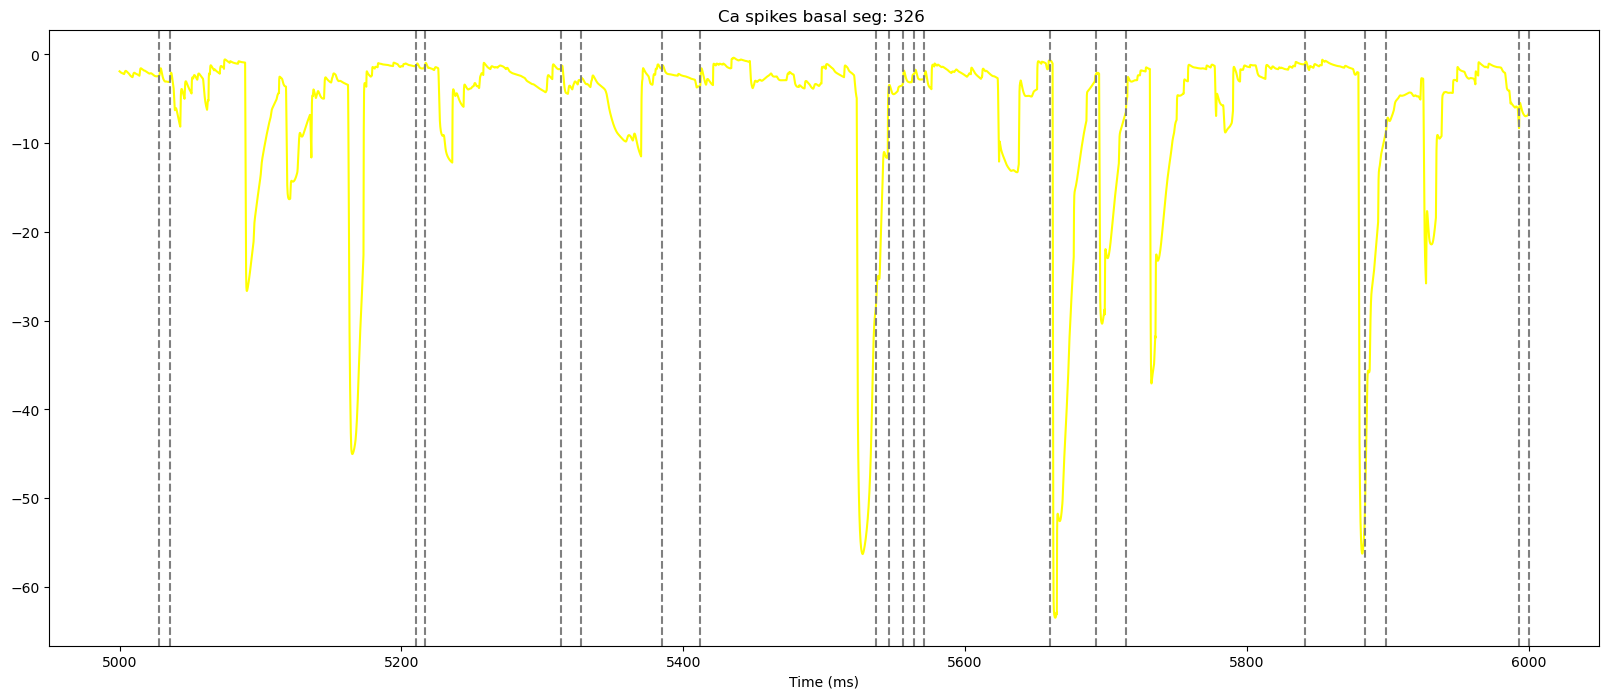

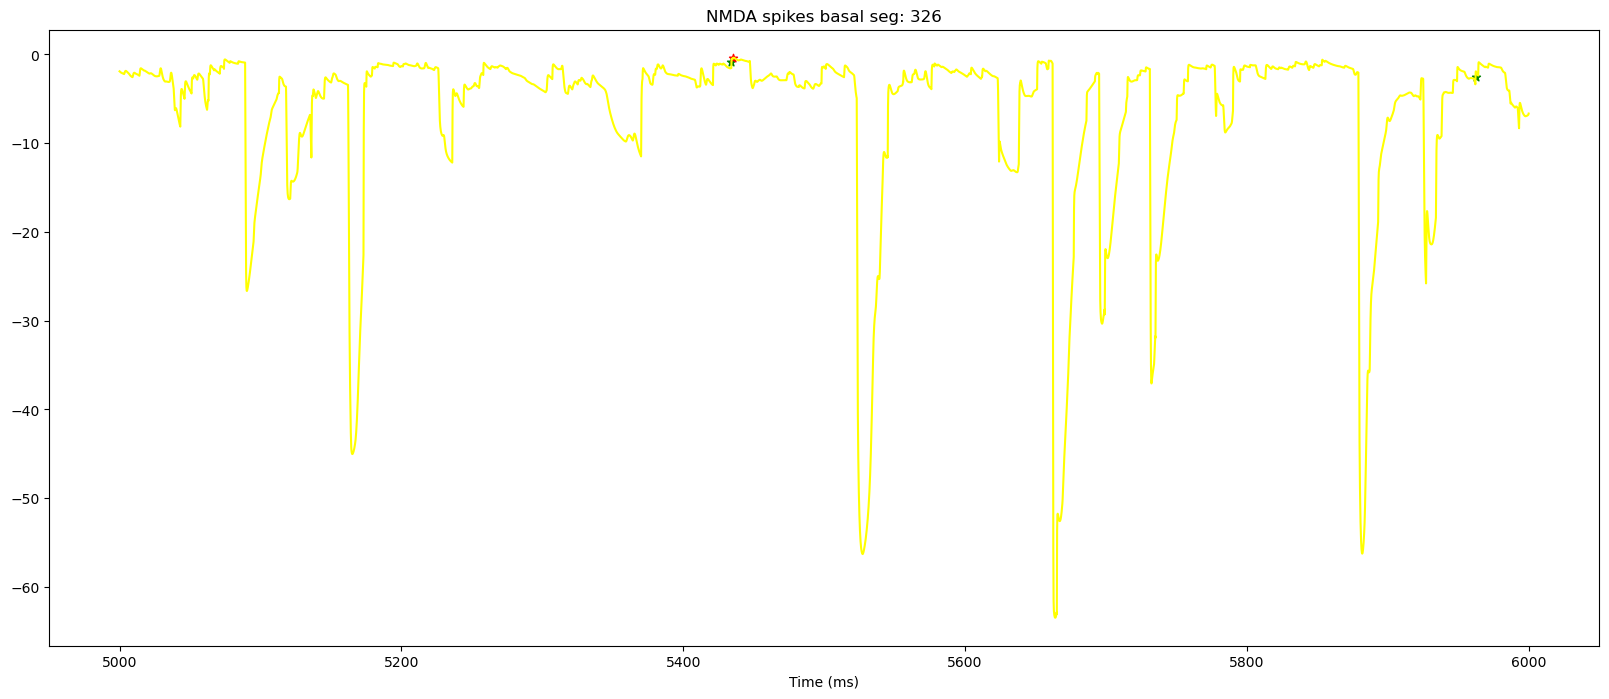

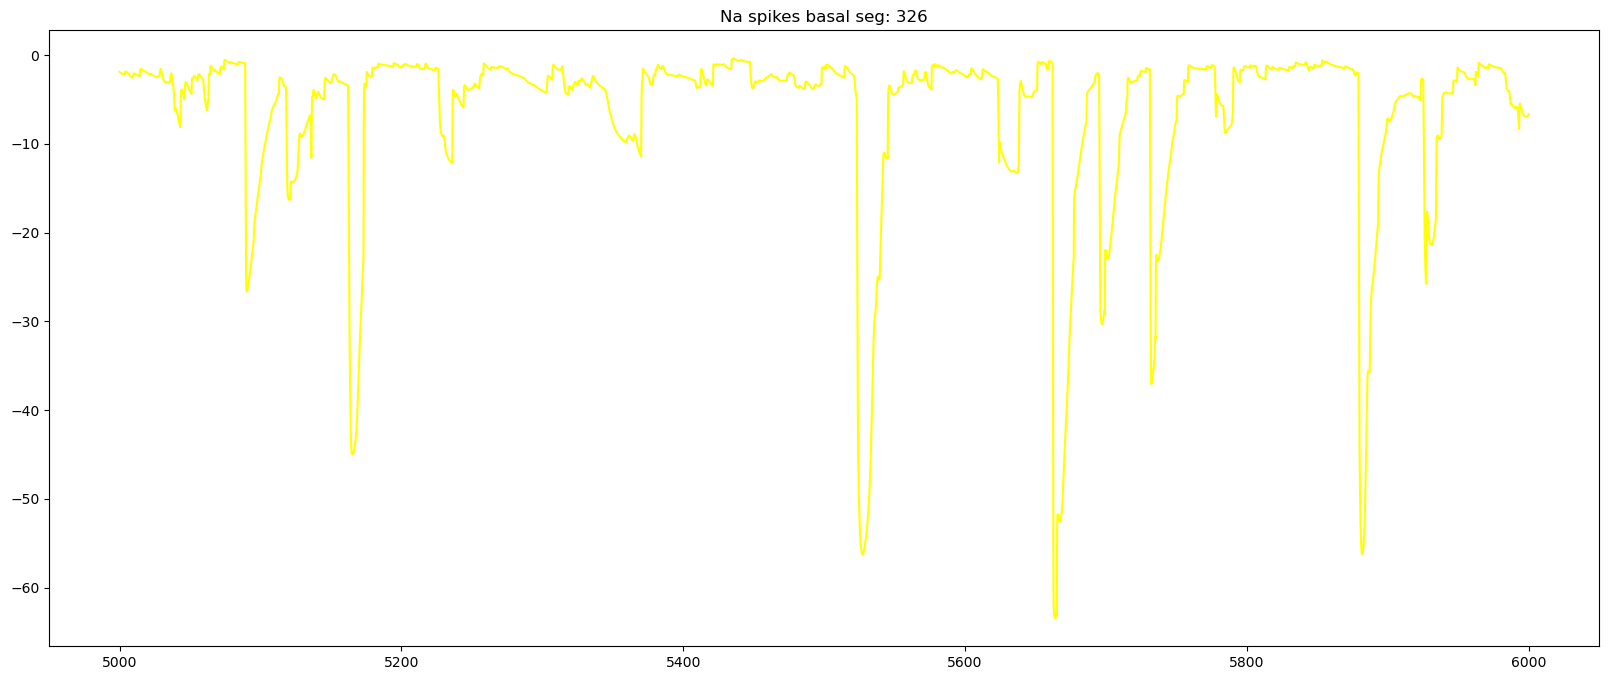

In [15]:
start_step = 50000
end_step = 60000
t = np.arange(0, (parameters.h_tstop)+parameters.h_dt, parameters.h_dt)

[1842, 1780, 1210, 1080]
plot_specs = { # organize these from near soma to far from soma.
    # 'nexus': {
    #     'seg_ids_to_plot':[1910],#[2000],#[1794], # [1545], # Complex
    #     # 'seg_ids_to_plot': [299], # Reduced
    #     'spike_types_to_plot': ['Ca'],
    #     'color': 'green'
    #     },
    # 'distal_tuft': {
    #     'seg_ids_to_plot':[2000],#[1844],#[1700, 1887, 2000], # Complex
    #     # 'seg_ids_to_plot': [736],
    #     'spike_types_to_plot': ['nmda', 'na'],
    #     'color': 'red'
    # },
    # 'mid_tuft': {
    #     # 'seg_ids_to_plot': [], # Complex
    #     'seg_ids_to_plot': [453, 599], # Reduced
    #     'spike_types_to_plot': ['nmda', 'na'],
    #     'color': 'blue'
    # },
    'basal': {
        'seg_ids_to_plot': [326], # Complex
        # 'seg_ids_to_plot': [1066], # Reduced
        'spike_types_to_plot': ['nmda', 'na'],
        'color': 'yellow'
    },
    # 'dist_basal': {
    #     # 'seg_ids_to_plot': [], # Complex
    #     'seg_ids_to_plot': [1220, 1103], # Reduced
    #     'spike_types_to_plot': ['nmda', 'na'],
    #     'color': 'blue'
    # # },
    # 'middle_oblique': {
    #     'seg_ids_to_plot': [1210],#[1300] # Complex
    #     # 'seg_ids_to_plot': [1727] # reduced
    #     'spike_types_to_plot': ['nmda', 'na'],
    #     'color': 'blue'
    # },
    # # 'dist_oblique': {
    # #     # 'seg_ids_to_plot': [], # Complex
    # #     'seg_ids_to_plot': [1612], # Reduced
    # #     'spike_types_to_plot': ['nmda', 'na'],
    # #     'color': 'blue'
    # # },
    # 'dist_trunk': {
    #     # 'seg_ids_to_plot': [], # Complex
    #     'seg_ids_to_plot': [201], # Reduced
    #     'spike_types_to_plot': ['nmda', 'na'],
    #     'color': 'blue'
    # },
}

plot_soma_spike_times = True

if parameters.record_all_channels:
    for region, region_params in plot_specs.items():
        # pick the segment indices
        # seg_id_to_plot = 1545
        for seg_id_to_plot in region_params['seg_ids_to_plot']:
            # mark them on morphology (can use above)

            # read the csvs at the desired segments
            ca_df = pd.read_csv(os.path.join(sim_directory,"ca.csv"))

            spike_start_times = ca_df[ca_df['segmentID'] == seg_id_to_plot].ca_lower_bound
            spike_start_times_to_use = spike_start_times[(spike_start_times < end_step) & (spike_start_times > start_step)]
            spike_start_times_to_use = np.array(spike_start_times_to_use).astype(int)


            plt.figure(figsize=(20,8))
            # plot voltage of the segment and mark spike times
            plt.plot(t[start_step:end_step], sim_data['v'][start_step:end_step, seg_id_to_plot], color = region_params['color'])
            
            plt.scatter(t[spike_start_times_to_use], sim_data['v'][spike_start_times_to_use, seg_id_to_plot], marker='*', color='green')

            if plot_soma_spike_times:
                soma_spike_times_to_plot = sim_data['spktimes'][np.array(sim_data['spktimes'] < max(t[start_step:end_step])) & np.array(sim_data['spktimes'] > min(t[start_step:end_step]))]
                for event_time in soma_spike_times_to_plot:
                    plt.axvline(event_time, linestyle='--', color='grey')

            # plot end times
            spike_start_times = ca_df[ca_df['segmentID'] == seg_id_to_plot].ca_upper_bound
            spike_start_times_to_use = spike_start_times[(spike_start_times < end_step) & (spike_start_times > start_step)]
            spike_start_times_to_use = np.array(spike_start_times_to_use).astype(int)

            plt.scatter(t[spike_start_times_to_use], sim_data['v'][spike_start_times_to_use, seg_id_to_plot], marker='*', color='red')

            plt.xlabel('Time (ms)')
            plt.title(f"Ca spikes {region} seg: {seg_id_to_plot} ")
            save_file = os.path.join(sim_directory, f"{region}_Ca_spikes")
            # plt.savefig(f"{save_file}_{seg_id_to_plot}.png", format='png', bbox_inches="tight", dpi=300)

            ### NMDA
            nmda_df = pd.read_csv(os.path.join(sim_directory, "nmda.csv"))

            spike_start_times = nmda_df[nmda_df['segmentID'] == seg_id_to_plot].nmda_lower_bound
            spike_start_times_to_use = spike_start_times[(spike_start_times < end_step) & (spike_start_times > start_step)]
            spike_start_times_to_use = np.array(spike_start_times_to_use).astype(int)

            plt.figure(figsize=(20,8))
            # plot voltage of the segment and mark spike times
            plt.plot(t[start_step:end_step], sim_data['v'][start_step:end_step, seg_id_to_plot], color = region_params['color'])
            plt.scatter(t[spike_start_times_to_use], sim_data['v'][spike_start_times_to_use, seg_id_to_plot], marker='*', color='green')
            # plot end times
            spike_start_times = nmda_df[nmda_df['segmentID'] == seg_id_to_plot].nmda_upper_bound
            spike_start_times_to_use = spike_start_times[(spike_start_times < end_step) & (spike_start_times > start_step)]
            spike_start_times_to_use = np.array(spike_start_times_to_use).astype(int)
            plt.scatter(t[spike_start_times_to_use], sim_data['v'][spike_start_times_to_use, seg_id_to_plot], marker='*', color='red')
            plt.xlabel('Time (ms)')
            plt.title(f"NMDA spikes {region} seg: {seg_id_to_plot}")
            save_file = os.path.join(sim_directory, f"{region}_NMDA_spikes")
            # plt.savefig(f"{save_file}_{seg_id_to_plot}.png", format='png', bbox_inches="tight", dpi=300)

            ## Na
            na_df = pd.read_csv(os.path.join(sim_directory, "na.csv"))

            spike_start_times = na_df[na_df['segmentID'] == seg_id_to_plot].na_lower_bound
            spike_start_times_to_use = spike_start_times[(spike_start_times < end_step) & (spike_start_times > start_step)]
            spike_start_times_to_use = np.array(spike_start_times_to_use).astype(int)

            plt.figure(figsize=(20,8))
            # plot voltage of the segment and mark spike times
            plt.plot(t[start_step:end_step], sim_data['v'][start_step:end_step, seg_id_to_plot], color = region_params['color'])
            plt.scatter(t[spike_start_times_to_use], sim_data['v'][spike_start_times_to_use, seg_id_to_plot], marker='*', color='green')
            plt.title(f"Na spikes {region} seg: {seg_id_to_plot}")
            save_file = os.path.join(sim_directory, f"{region}_Na_spikes")
            # plt.savefig(f"{save_file}_{seg_id_to_plot}.png", format='png', bbox_inches="tight", dpi=300)

            # # plot end times
            # spike_start_times = na_df[na_df['segmentID'] == seg_id_to_plot].na_upper_bound
            # spike_start_times_to_use = spike_start_times[(spike_start_times < end_step) & (spike_start_times > start_step)]
            # spike_start_times_to_use = np.array(spike_start_times_to_use).astype(int)
            # plt.scatter(t[spike_start_times_to_use], sim_data['v'][spike_start_times_to_use, seg_id_to_plot], marker='*', color='red')
            # plt.xlabel('Time (ms)')

In [16]:
np.shape(sim_data['v'])

(500001, 2630)

In [17]:
ca_df[ca_df['segmentID'] == 1900].ca_lower_bound

140543      1561.0
140544      2549.0
140545      3558.0
140546      4725.0
140547      5165.0
            ...   
141038    484761.0
141039    485826.0
141040    486527.0
141041    487166.0
141042    488189.0
Name: ca_lower_bound, Length: 500, dtype: float64

## calculate average voltage of each segment type

In [18]:
sim_data['v'].shape

(500001, 2630)

In [19]:
seg_mean_vs = []
for i, seg in seg_data.iterrows():
    seg_mean_v = np.mean(sim_data['v'][:,i])
    seg_mean_vs.append(seg_mean_v)

In [20]:
seg_data['mean_v'] = seg_mean_vs

In [21]:
seg_data

,section,idx_in_section_type,seg_half_seg_RA,L,length,seg,pseg,Section_L,Section_diam,Distance,...,Type,Coord X,Coord Y,Coord Z,Elec_distance,Elec_distance_nexus,X,segmentID,Elec_distanceQ,mean_v
0,soma,0,0.081276,23.169408,23.169408,L5PCtemplate[0].soma[0](0.5),NaN,23.169408,13.471518,0.000000,...,soma,45.725557,18.343678,-50.250000,1.000000,0.290558,0.500000,0,None,-61.149147
1,dend,0,2.647135,4.840176,4.840176,L5PCtemplate[0].dend[0](0.1),L5PCtemplate[0].soma[0](0.5),24.200878,1.170000,2.420088,...,dend,58.736230,20.787594,-50.027254,0.896041,0.260352,0.100000,1,9,-60.685200
2,dend,0,2.250969,4.840176,4.840176,L5PCtemplate[0].dend[0](0.3),L5PCtemplate[0].dend[0](0.1),24.200878,1.170000,7.260263,...,dend,62.939716,21.939324,-50.557475,0.781280,0.227007,0.300000,2,9,-60.021236
3,dend,0,2.250969,4.840176,4.840176,L5PCtemplate[0].dend[0](0.5),L5PCtemplate[0].dend[0](0.3),24.200878,1.170000,12.100439,...,dend,66.929149,21.040891,-51.991813,0.684892,0.199001,0.500000,3,9,-59.274460
4,dend,0,2.250969,4.840176,4.840176,L5PCtemplate[0].dend[0](0.7),L5PCtemplate[0].dend[0](0.5),24.200878,1.170000,16.940615,...,dend,69.673642,19.672918,-48.246989,0.605617,0.175967,0.700000,4,9,-58.377216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2625,axon,0,2.938245,4.615385,4.615385,L5PCtemplate[0].axon[0](0.653846),L5PCtemplate[0].axon[0](0.576923),60.000004,1.000000,39.230772,...,axon,45.725559,57.574449,-50.250000,0.303371,0.088147,0.653846,2625,None,-61.208576
2626,axon,0,2.938245,4.615385,4.615385,L5PCtemplate[0].axon[0](0.730769),L5PCtemplate[0].axon[0](0.653846),60.000004,1.000000,43.846157,...,axon,45.725559,62.189834,-50.250000,0.278065,0.080794,0.730769,2626,None,-61.211765
2627,axon,0,2.938245,4.615385,4.615385,L5PCtemplate[0].axon[0](0.807692),L5PCtemplate[0].axon[0](0.730769),60.000004,1.000000,48.461542,...,axon,45.725559,66.805219,-50.250000,0.256554,0.074544,0.807692,2627,None,-61.214142
2628,axon,0,2.938245,4.615385,4.615385,L5PCtemplate[0].axon[0](0.884615),L5PCtemplate[0].axon[0](0.807692),60.000004,1.000000,53.076926,...,axon,45.725559,71.420604,-50.250000,0.238060,0.069170,0.884615,2628,None,-61.215736


Text(0.5, 0, 'segment transfer ratio from soma (1 is soma)')

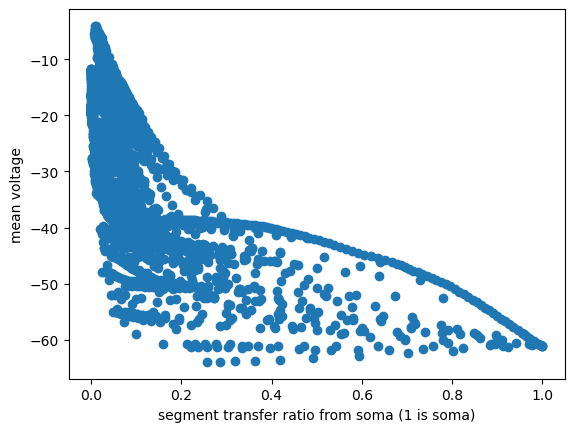

In [22]:
elec_dist_to_plot = seg_data['Elec_distance'][np.argsort(seg_data['Elec_distance'])]
avg_v_to_plot = seg_data['mean_v'][np.argsort(seg_data['Elec_distance'])]

plt.scatter(elec_dist_to_plot, avg_v_to_plot)
plt.ylabel('mean voltage')
plt.xlabel('segment transfer ratio from soma (1 is soma)')

In [23]:
[min(seg_data['mean_v']), max(seg_data['mean_v'])]

[-63.95875930786133, -4.039096832275391]

In [24]:
sim_directory

'/home/drfrbc/Neural-Modeling/simulations/2025-10-22-14-15-Testing_IncreaseTuftInh/allinh_delay_shift_4ms_Np5000'

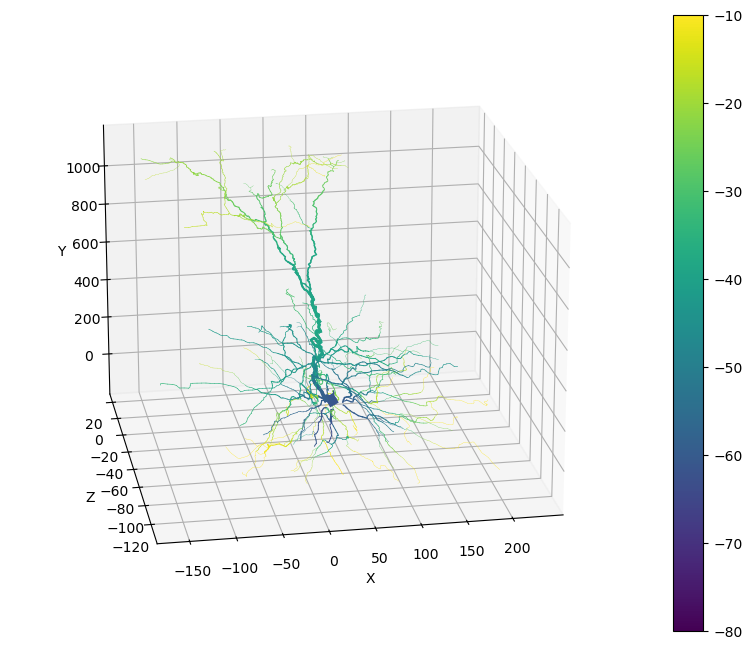

In [25]:
from Modules import plot_morphology
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
# plot_morphology.plot(seg_data,  seg_data['mean_v'], ax, clims = [min(seg_data['mean_v']), max(seg_data['mean_v'])], radius_scale=1.5)
fig = plot_morphology.plot(seg_data,  seg_data['mean_v'], ax, clims = [-80, -10], radius_scale=1.5)
ax.clabel('mean voltage')
plt.savefig(os.path.join(sim_directory, 'mean_v_morphology'))

## Calculate FFT of voltage to look for artifcats from rhythmic inhibition

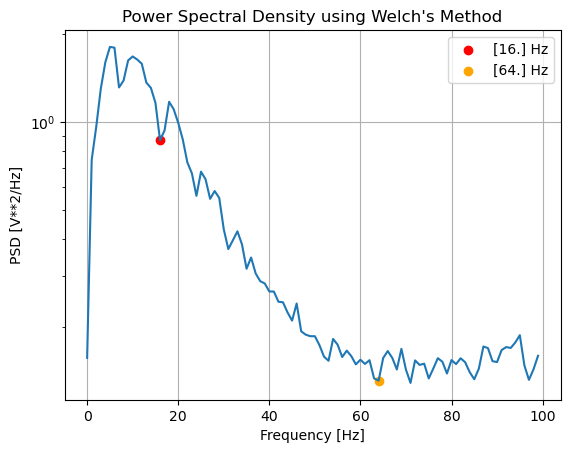

In [26]:
# check PSD

from scipy.signal import welch
signal = sim_data['v'][:,0] #1644

# Compute PSD using Welch's method
f, Pxx = welch(signal, fs=10000, nperseg=10000)

Pxx = Pxx[f<100]
f=f[f<100]

# Plot the result
# plt.subplots(1,2)
# plt.subplot(121)
# plt.plot(signal)

# plt.subplot(122)
plt.semilogy(f, Pxx)
plt.scatter(f[f-16==min(abs(f-16))], Pxx[f-16==min(abs(f-16))], c='r', label=f'{f[f-16==min(abs(f-64))]} Hz')
plt.scatter(f[abs(f-64)==min(abs(f-64))], Pxx[abs(f-64)==min(abs(f-64))], c='orange', label=f'{f[abs(f-64)==min(abs(f-64))]} Hz')
# plt.semilogy(f, 100/f)
plt.title('Power Spectral Density using Welch\'s Method')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
f[f-16==min(abs(f-16))]

array([16.])

In [28]:
f

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
       52., 53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64.,
       65., 66., 67., 68., 69., 70., 71., 72., 73., 74., 75., 76., 77.,
       78., 79., 80., 81., 82., 83., 84., 85., 86., 87., 88., 89., 90.,
       91., 92., 93., 94., 95., 96., 97., 98., 99.])

In [29]:

f[Pxx == max(Pxx)]

array([5.])

Spike raster

In [30]:
# read synapse_data.h5 from our simulations.
def read_synapse_distribution_file(sim_directory):
    """
    Reads the synapse_data.h5 file and loads its datasets into a Pandas DataFrame.

    Parameters:
        sim_directory (str): Path to the directory containing synapse_data.h5.

    Returns:
        pd.DataFrame: A DataFrame where each column corresponds to a dataset in the HDF5 file.
    """
    # Construct the full file path
    synapse_file_path = os.path.join(sim_directory, 'synapse_data.h5')

    # Check if the file exists
    if not os.path.exists(synapse_file_path):
        raise FileNotFoundError(f"File not found: {synapse_file_path}")

    # Dictionary to temporarily store the data
    synapse_data = {}

    # Read the HDF5 file
    with h5py.File(synapse_file_path, 'r') as h5f:
        # Load all datasets into the dictionary
        for key in h5f.keys():
            synapse_data[key] = h5f[key][()]  # Load dataset into memory as NumPy array

    # Convert the dictionary into a Pandas DataFrame
    synapse_df = pd.DataFrame(synapse_data)

    return synapse_df

def read_transfer_impedance_file(sim_directory, loc='soma'):
    # loc can be nexus
    imp_file = os.path.join(sim_directory, f"elec_distance_{loc}.csv")
    impedance_data = pd.read_csv(imp_file)
    return impedance_data

def add_seg_info_to_syn_data(syn_data, seg_data):
    """
    Adds segment information (Distance and section) from seg_data to syn_data
    using the seg_id as a lookup.

    Parameters:
        syn_data (pd.DataFrame): DataFrame containing synapse data with 'seg_id'.
        seg_data (pd.DataFrame): DataFrame containing segment data.

    Returns:
        pd.DataFrame: Updated syn_data with 'Distance' and 'section' columns added.
    """
    # Set 'Unnamed: 0' as the index in seg_data for easy lookup
    seg_data_indexed = seg_data.set_index('Unnamed: 0')

    # Use .loc to map the segment information to syn_data based on seg_id
    syn_data['Distance'] = syn_data['seg_id'].map(seg_data_indexed['Distance'])
    syn_data['section'] = syn_data['seg_id'].map(seg_data_indexed['section'])
    syn_data['soma_trans_imp'] = syn_data['seg_id'].map(seg_data_indexed['soma_trans_imp'])
    syn_data['seg_L'] = syn_data['seg_id'].map(seg_data_indexed['L'])

    # Convert the 'synapse_type' column from bytes to strings

# read synapses from our simulation and ben's
syn_data = read_synapse_distribution_file(sim_directory)

# read segment data from our simulation
seg_data = pd.read_csv(os.path.join(sim_directory, "segment_data.csv"))

# read transfer impedances
imp_df = read_transfer_impedance_file(sim_directory, loc='soma')
seg_data['soma_trans_imp'] = imp_df.beta_active

# add segment information of synapse location
# syn_data = add_seg_info_to_syn_data(syn_data, seg_data)

FileNotFoundError: File not found: /home/drfrbc/Neural-Modeling/simulations/2025-10-22-14-15-Testing_IncreaseTuftInh/allinh_delay_shift_4ms_Np5000/synapse_data.h5

In [ ]:
print(syn_data)

In [ ]:
syn_data